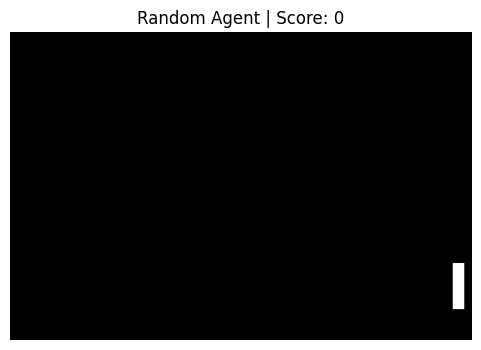

에피소드 종료! 최종 점수: 0


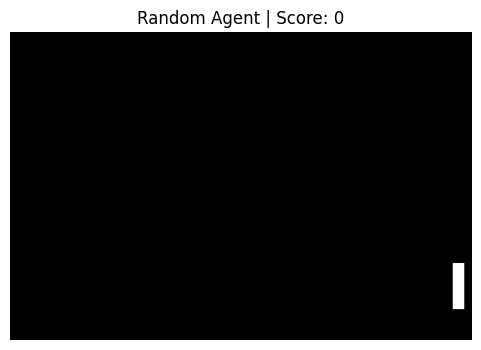

In [ ]:
import os
# 코랩(헤드리스 환경)에서 Pygame 창 에러를 방지하는 핵심 코드
os.environ["SDL_VIDEODRIVER"] = "dummy"

import pygame
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython import display
import time

# ==========================================
# 1. 환경 설정 상수
# ==========================================
WIDTH, HEIGHT = 600, 400
PADDLE_WIDTH, PADDLE_HEIGHT = 15, 60
BALL_SIZE = 10

# 색상
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
RED = (255, 50, 50)

class PongSurvivalEnvColab:
    def __init__(self):
        pygame.init()
        self.screen = pygame.display.set_mode((WIDTH, HEIGHT))
        self.action_space = 3
        self.state_space = 5 
        self.reset()

    def reset(self):
        self.paddle_y = HEIGHT // 2 - PADDLE_HEIGHT // 2
        self.paddle_x = WIDTH - PADDLE_WIDTH - 10
        self.paddle_speed = 10
        
        self.ball_x = WIDTH // 2
        self.ball_y = HEIGHT // 2
        
        self.ball_dx = random.choice([5, 6])
        self.ball_dy = random.choice([-5, -4, 4, 5])
        
        self.score = 0
        return self._get_state()

    def _get_state(self):
        state = [
            self.paddle_y / HEIGHT,
            self.ball_x / WIDTH,
            self.ball_y / HEIGHT,
            self.ball_dx / 10.0,
            self.ball_dy / 10.0
        ]
        return np.array(state, dtype=np.float32)

    def step(self, action):
        reward = 0
        done = False

        # 1. 패들 이동
        if action == 0:   # Up
            self.paddle_y -= self.paddle_speed
        elif action == 2: # Down
            self.paddle_y += self.paddle_speed

        self.paddle_y = max(0, min(HEIGHT - PADDLE_HEIGHT, self.paddle_y))

        # 2. 공 이동
        self.ball_x += self.ball_dx
        self.ball_y += self.ball_dy

        if self.ball_y <= 0 or self.ball_y >= HEIGHT - BALL_SIZE:
            self.ball_dy *= -1
        if self.ball_x <= 0:
            self.ball_dx *= -1
            self.ball_x = 0

        # 3. AI 패들 충돌 판정
        hit_x = (self.ball_x + BALL_SIZE >= self.paddle_x) and (self.ball_x <= self.paddle_x + PADDLE_WIDTH)
        hit_y = (self.ball_y + BALL_SIZE >= self.paddle_y) and (self.ball_y <= self.paddle_y + PADDLE_HEIGHT)
        
        if hit_x and hit_y:
            self.ball_dx *= -1 
            self.ball_x = self.paddle_x - BALL_SIZE 
            reward = 1.0 
            self.score += 1
            self.ball_dx = min(self.ball_dx * 1.05, 15) if self.ball_dx > 0 else max(self.ball_dx * 1.05, -15)

        # 4. 공 놓침
        if self.ball_x > WIDTH:
            reward = -1.0
            done = True

        return self._get_state(), reward, done, self.score

    def render_frame(self):
        """코랩 화면 출력을 위해 Pygame 화면을 Numpy 이미지 배열로 변환"""
        self.screen.fill(BLACK)
        pygame.draw.rect(self.screen, WHITE, (self.paddle_x, self.paddle_y, PADDLE_WIDTH, PADDLE_HEIGHT))
        pygame.draw.ellipse(self.screen, RED, (self.ball_x, self.ball_y, BALL_SIZE, BALL_SIZE))
        
        # Pygame Surface를 3D Numpy Array로 변환 후 축 변환(Transpose)
        view = pygame.surfarray.array3d(self.screen)
        view = view.transpose([1, 0, 2])
        return view

# ==========================================
# 코랩용 시각화 테스트 (깜빡임 완벽 제거 버전)
# ==========================================
env = PongSurvivalEnvColab()
state = env.reset()
done = False

# 1. 초기 도화지(Figure)와 액자(AxesImage) 세팅
fig, ax = plt.subplots(figsize=(6, 4))
frame = env.render_frame()
im = ax.imshow(frame) # 액자에 첫 프레임 끼우기
ax.axis('off')

# 💡 2. 디스플레이 핸들 생성 (화면을 지우지 않고 갱신하기 위한 핵심!)
dh = display.display(fig, display_id=True)

while not done:
    # 랜덤 행동 선택
    action = random.choice([0, 1, 2])
    state, reward, done, score = env.step(action)
    
    # 새로운 프레임 캡처
    frame = env.render_frame()
    
    # 💡 3. 도화지를 비우지 않고, 기존 액자의 데이터와 제목만 덮어쓰기
    im.set_data(frame)
    ax.set_title(f"Random Agent | Score: {score}")
    
    # 💡 4. 핸들을 통해 부드럽게 갱신
    dh.update(fig) 
    
    # 코랩 웹 환경에서 부드러운 애니메이션을 위한 적정 대기 시간 (약 30~50fps)
    time.sleep(0.02) 

print(f"에피소드 종료! 최종 점수: {score}")
plt.close(fig) # 루프가 끝나면 메모리에서 피규어 닫기

사용 중인 디바이스: cuda
Episode:   50 | Avg Score (last 50):    0.1 | Epsilon: 0.778
Episode:  100 | Avg Score (last 50):    0.4 | Epsilon: 0.606
Episode:  150 | Avg Score (last 50):    0.7 | Epsilon: 0.471
Episode:  200 | Avg Score (last 50):    2.2 | Epsilon: 0.367
Episode:  250 | Avg Score (last 50):    5.0 | Epsilon: 0.286
Episode:  300 | Avg Score (last 50):    3.8 | Epsilon: 0.222
Episode:  350 | Avg Score (last 50):    4.9 | Epsilon: 0.173
Episode:  400 | Avg Score (last 50):    4.1 | Epsilon: 0.135
Episode:  450 | Avg Score (last 50):    5.8 | Epsilon: 0.105
Episode:  500 | Avg Score (last 50):    4.2 | Epsilon: 0.082

✅ 학습 완료 및 모델 가중치 저장 (pong_dqn_weights.pth)


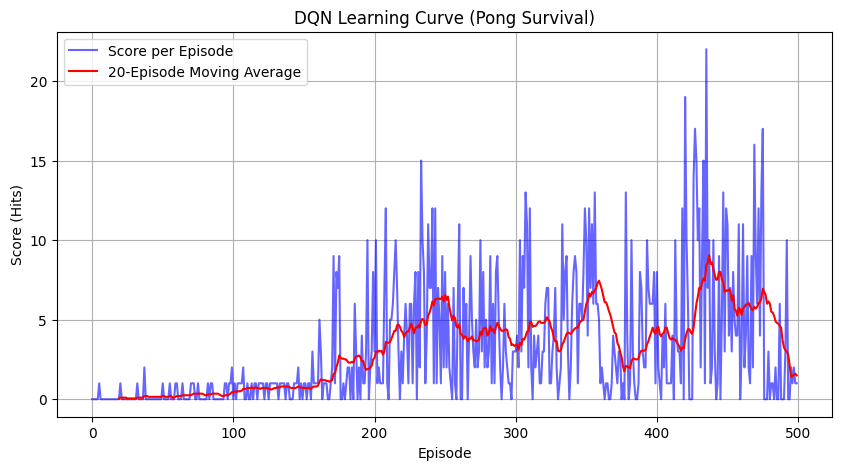

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ==========================================
# 1. 하이퍼파라미터 및 디바이스 설정
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 디바이스: {DEVICE}")

BATCH_SIZE = 64
GAMMA = 0.99
LR = 1e-3
TARGET_UPDATE_FREQ = 10
MEMORY_CAPACITY = 10000

EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995  # 에피소드마다 곱해지는 감쇠율

# ==========================================
# 2. DQN 아키텍처 (MLP 구조)
# ==========================================
class PongDQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PongDQN, self).__init__()
        # 상태 공간이 5차원이므로 가벼운 Linear 레이어로 충분합니다.
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# ==========================================
# 3. 리플레이 버퍼
# ==========================================
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)

# ==========================================
# 4. 고속 학습 루프 (Rendering 제거)
# ==========================================
env = PongSurvivalEnvColab()

policy_net = PongDQN(env.state_space, env.action_space).to(DEVICE)
target_net = PongDQN(env.state_space, env.action_space).to(DEVICE)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayBuffer(MEMORY_CAPACITY)

epsilon = EPSILON_START
episodes = 500  # 실습용으로는 500~1000 번이면 충분히 수렴합니다.
scores_history = []

for ep in range(episodes):
    state = env.reset()
    score = 0
    done = False
    
    while not done:
        # Epsilon-Greedy 행동 선택
        if random.random() < epsilon:
            action = random.choice([0, 1, 2])
        else:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                q_values = policy_net(state_t)
            action = q_values.argmax().item()

        # 환경 진행 (시각화 없음 -> 연산 속도 극대화)
        next_state, reward, done, current_score = env.step(action)
        score = current_score

        # 버퍼에 경험 저장
        memory.push(state, action, reward, next_state, done)
        state = next_state

        # 모델 학습
        if len(memory) > BATCH_SIZE:
            s_batch, a_batch, r_batch, s_next_batch, d_batch = memory.sample(BATCH_SIZE)
            
            s_batch = torch.FloatTensor(s_batch).to(DEVICE)
            a_batch = torch.LongTensor(a_batch).unsqueeze(1).to(DEVICE)
            r_batch = torch.FloatTensor(r_batch).unsqueeze(1).to(DEVICE)
            s_next_batch = torch.FloatTensor(s_next_batch).to(DEVICE)
            d_batch = torch.FloatTensor(d_batch).unsqueeze(1).to(DEVICE)

            q_eval = policy_net(s_batch).gather(1, a_batch)
            with torch.no_grad():
                q_next = target_net(s_next_batch).max(1)[0].unsqueeze(1)
                q_target = r_batch + GAMMA * q_next * (1 - d_batch)

            loss = F.mse_loss(q_eval, q_target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # 타겟 네트워크 업데이트
    if ep % TARGET_UPDATE_FREQ == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Epsilon 감쇠
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    scores_history.append(score)

    # 50 에피소드마다 진행 상황 로그 출력
    if (ep + 1) % 50 == 0:
        avg_score = np.mean(scores_history[-50:])
        print(f"Episode: {ep+1:4d} | Avg Score (last 50): {avg_score:6.1f} | Epsilon: {epsilon:.3f}")

# 학습 완료 후 가중치 저장
torch.save(policy_net.state_dict(), "pong_dqn_weights.pth")
print("\n✅ 학습 완료 및 모델 가중치 저장 (pong_dqn_weights.pth)")

# ==========================================
# 5. 학습 결과(Reward Curve) 그래프 출력
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(scores_history, alpha=0.6, color='blue', label='Score per Episode')
# 20 이동 평균선 추가
moving_avg = np.convolve(scores_history, np.ones(20)/20, mode='valid')
plt.plot(range(19, len(scores_history)), moving_avg, color='red', label='20-Episode Moving Average')
plt.title("DQN Learning Curve (Pong Survival)")
plt.xlabel("Episode")
plt.ylabel("Score (Hits)")
plt.legend()
plt.grid(True)
plt.show()